## Imports

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from mdm2_breaker import (
    GraphSiameseNetwork,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer_v5,
    generate_scaffold_split,
    plot_loss,
    train_model,
    view_protein,
    visualize_scaffold_split,
    load_model_from_checkpoint,
    SmallMoleculeFeaturizer_DeepPurpose,
    plot_predictions,
    get_metrics
)

ROOT = Path(os.getcwd()).parents[0]



## Constants

In [2]:
BS = 256
EPOCHS = 50
LR = 0.001

## Utility Functions

In [3]:
def get_latest_checkpoint(checkpoint_dir="checkpoints"):
    # 1. Define the path
    p = Path(checkpoint_dir)
    
    # 2. Get all .ckpt files
    files = list(p.glob("*.ckpt"))
    
    # 3. Guard clause: Return None if empty
    if not files:
        return None
        
    # 4. Find the file with the most recent modification time (st_mtime)
    latest_file = max(files, key=lambda f: f.stat().st_mtime)
    
    return str(latest_file)


## Data Analysis

In [4]:
mol_file = os.path.join(
    "..", "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

BENCHMARK_DATA_PATH = os.path.join('..', 'data', 'MDM2_Breaker', 'processed', 'benchmark_data.csv')

df_mol = pd.read_csv(BENCHMARK_DATA_PATH)

def is_valid_molecule(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

# Drop rows with invalid SMILES
df_mol = df_mol[df_mol['SMILES'].apply(is_valid_molecule)]

def sanitize_and_flatten(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        # CRITICAL FIX: Remove the "Wedge/Dash" bond directions
        # This prevents the 'BEGINDASH' error in DGL-LifeSci
        Chem.RemoveStereochemistry(mol)
        
        # Return the canonical, flattened SMILES
        return Chem.MolToSmiles(mol)
    except:
        return None

# 1. Apply the cleaner
df_mol['SMILES'] = df_mol['SMILES'].apply(sanitize_and_flatten)
# 2. Drop rows that failed (became None)
df_mol = df_mol.dropna(subset=['SMILES']).reset_index(drop=True)

train_indices = df_mol[df_mol['split'] == 'train'].index.tolist()
val_indices = df_mol[df_mol['split'] == 'val'].index.tolist()
test_indices = df_mol[df_mol['split'] == 'test'].index.tolist()

## Modeling

In [5]:
from mdm2_breaker.graph_dta_model import GraphDTAModel
MDM2_SEQUENCE = "SQIPASEQETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDEKQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVVVNQQESSDSGTSVSEN"
SAVE_NAME = "GraphDTA-updated"
# Simple Amino Acid Vocabulary
AA_VOCAB = "ACDEFGHIKLMNPQRSTVWY"  # The 20 standard
char_to_int = {c: i + 1 for i, c in enumerate(AA_VOCAB)}  # Start at 1, 0 is padding


def tokenize_sequence(seq, max_len=1000):
    # Convert chars to ints, ignoring unknown chars
    indices = [char_to_int.get(c, 0) for c in seq]

    # Pad or Truncate
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]

    return torch.tensor(indices, dtype=torch.long)


# Usage
mdm2_tensor = tokenize_sequence(MDM2_SEQUENCE).unsqueeze(0)  # Add batch dim

df = pd.DataFrame()
for i in range(100):
    model_gdta, train_loader_gdta, val_loader_gdta, test_loader_gdta = train_model(
        model=GraphDTAModel(
            molecule_in_channels = 74
            ),
        mol_class=SmallMoleculeFeaturizer_DeepPurpose,
        protein_data=mdm2_tensor,
        train_indices=train_indices,
        val_indices=val_indices,
        test_indices=test_indices,
        epochs=EPOCHS,
        lr=LR,
        save_name=SAVE_NAME,
        train=True,
        mol_file=mol_file,
        batch_size=BS,
        seed=i,
    )

    # latest_loss_curve_idx = max([int(folder.split("_")[-1]) for folder in os.listdir("lightning_logs") if folder.startswith("version_")])
    # latest_loss_curve = f"version_{latest_loss_curve_idx}"

    # plot_loss(os.path.join("lightning_logs", latest_loss_curve, "metrics.csv"))
    # print(f"latest_loss_curve: {latest_loss_curve}")

    latest_ckpt = get_latest_checkpoint()
    # print(f"Loading latest model from: {latest_ckpt}, {i}")

    # 1. Load the raw checkpoint
    checkpoint = torch.load(latest_ckpt)
    state_dict = checkpoint["state_dict"]

    # 2. Fix the keys (Remove "model." prefix)
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith("model."):
            # Strip the first 6 characters ("model.")
            new_key = key[6:]
            new_state_dict[new_key] = value

    # 3. Initialize your raw model
    model = GraphDTAModel(
        molecule_in_channels = 74
        )

    # 4. Load the cleaned weights
    model.load_state_dict(new_state_dict)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # print(f"\nTotal Trainable Parameters: {total_params:,}")

    model.eval()

    mse, r2, y_pred, y_true = get_metrics(
        model,
        test_loader_gdta,
        mdm2_tensor,
    )

    
    df_tmp = pd.DataFrame(columns=["seed", "mse", "r2"], data=[[i, mse, r2]], index=[0])
    df = pd.concat([df, df_tmp], ignore_index=True)

    df_preds = pd.DataFrame(columns=["y_pred", "y_true"])
    df_preds["y_pred"] = y_pred
    df_preds["y_true"] = y_true

    os.makedirs(os.path.join("data", "MDM2_Breaker", "processed", "random_seed_preds"), exist_ok=True)
    df_preds.to_csv(os.path.join("data", "MDM2_Breaker", "processed", "random_seed_preds", f"graphdta_benchmark_random_seed_preds_{i}.csv"), index=False)
    df.to_csv(os.path.join("data", "MDM2_Breaker", "processed", "graphdta_benchmark_random_seed_results.csv"), index=False)

    display(df)
    # plot_predictions(
    #     model,
    #     (train_loader_gdta, val_loader_gdta, test_loader_gdta),
    #     mdm2_tensor,
    #     "Graph DTA Model",
    # )

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)
Seed set to 0
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip insta

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GraphDTAModel │  2.3 M │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)
python(54795) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54796) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54797) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54798) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54799) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54800) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54807) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,seed,mse,r2
0,0,0.258156,0.642005
1,1,0.302041,0.581148
2,2,0.276186,0.617002
3,3,0.252399,0.649987
4,4,0.276036,0.617210
...,...,...,...
95,95,0.280260,0.611352
96,96,0.241861,0.664601
97,97,0.265891,0.631279
98,98,0.363454,0.495983


In [6]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smile_to_fingerprint(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return np.zeros((2048,), dtype=np.float32)

    # NEW CALL
    fp = mfpgen.GetFingerprintAsNumPy(mol)
    return fp


df_mol["fingerprint"] = df_mol["SMILES"].apply(smile_to_fingerprint)
df_mol.head()

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm,fingerprint,split
0,COc1ccc(CO)cc1-c1nc2c(n1C(C)C)C(c1ccc(Cl)cc1C)...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train
1,COc1ccc(C(=O)NCCO)cc1-c1nc2c(n1C(C)C)C(c1ccc(C...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",train
2,COCC(C)n1c(-c2cnc(N(C)C)nc2OC)nc2c1C(c1ccc(Cl)...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",val
3,CC1(CC(=O)O)CC(c2cccc(Cl)c2)C(c2ccc(Cl)cc2)N(C...,0.059000,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train
4,CC1(CC(=O)O)CC(c2cccc(Cl)c2)C(c2ccc(Cl)cc2)N(C...,0.059000,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",train


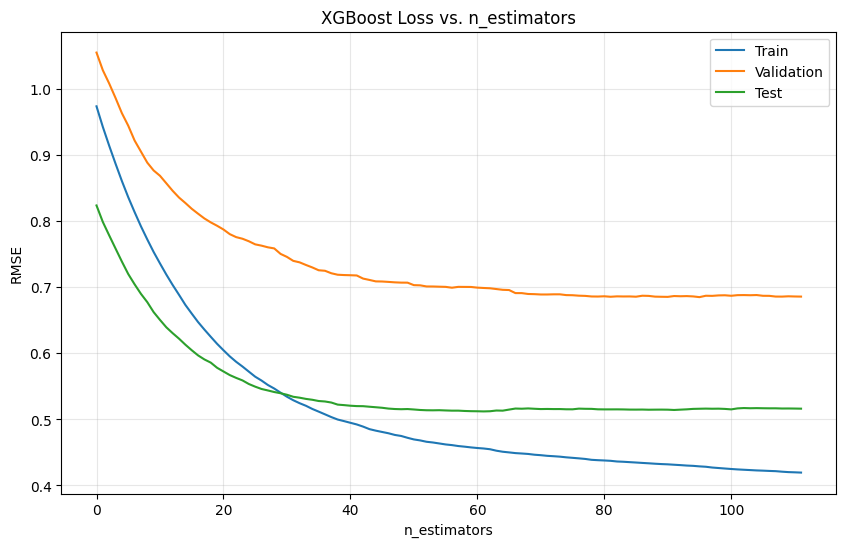

Best Iteration: 61
Best Score (Validation MSE): 0.5120


In [9]:
import xgboost as xgb
from mdm2_breaker import plot_xgb_loss, plot_xgboost_predictions
from sklearn.metrics import mean_squared_error, r2_score

# Apply to the CSV for XGBoost
train_df = df_mol[df_mol['split'] == 'train']
val_df = df_mol[df_mol['split'] == 'val']
test_df = df_mol[df_mol['split'] == 'test']

X_test = np.stack(np.array(test_df["fingerprint"]))
y_test = test_df["pIC50_norm"].values
X_train = np.stack(np.array(train_df["fingerprint"]))
y_train = train_df["pIC50_norm"].values
X_val = np.stack(np.array(val_df["fingerprint"]))
y_val = val_df["pIC50_norm"].values

df = pd.DataFrame()
for i in range(100):
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        random_state=i,
        early_stopping_rounds=50,
        subsample=0.8,         # Enable stochastic row sampling
        colsample_bytree=0.8,  # Enable stochastic feature sampling
        n_jobs=-1              # Use all cores
    )

    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val), (X_test, y_test)],
        verbose=False,
    )

    y_pred_train = xgb_model.predict(X_train)
    y_pred_val = xgb_model.predict(X_val)
    y_pred_test = xgb_model.predict(X_test)

    test_r2 = r2_score(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    train_mse = mean_squared_error(y_train, y_pred_train)
    val_r2 = r2_score(y_val, y_pred_val)
    val_mse = mean_squared_error(y_val, y_pred_val)
    
    
    df_tmp = pd.DataFrame(
        columns=["seed", "train_mse", "train_r2", "val_mse", "val_r2", "test_mse", "test_r2"], 
        data=[[i, train_mse, train_r2, val_mse, val_r2, test_mse, test_r2]], 
        index=[0]
        )
    df = pd.concat([df, df_tmp], ignore_index=True)

    df_preds = pd.DataFrame(columns=["y_pred", "y_true"])
    df_preds["y_pred"] = y_pred_test
    df_preds["y_true"] = y_test

    os.makedirs(os.path.join("data", "MDM2_Breaker", "processed", "xgboost_random_seed_preds"), exist_ok=True)
    df_preds.to_csv(os.path.join("data", "MDM2_Breaker", "processed", "xgboost_random_seed_preds", f"xgboost_benchmark_random_seed_preds_{i}.csv"), index=False)
    df.to_csv(os.path.join("data", "MDM2_Breaker", "processed", "xgboost_benchmark_random_seed_results.csv"), index=False)

plot_xgb_loss(xgb_model)

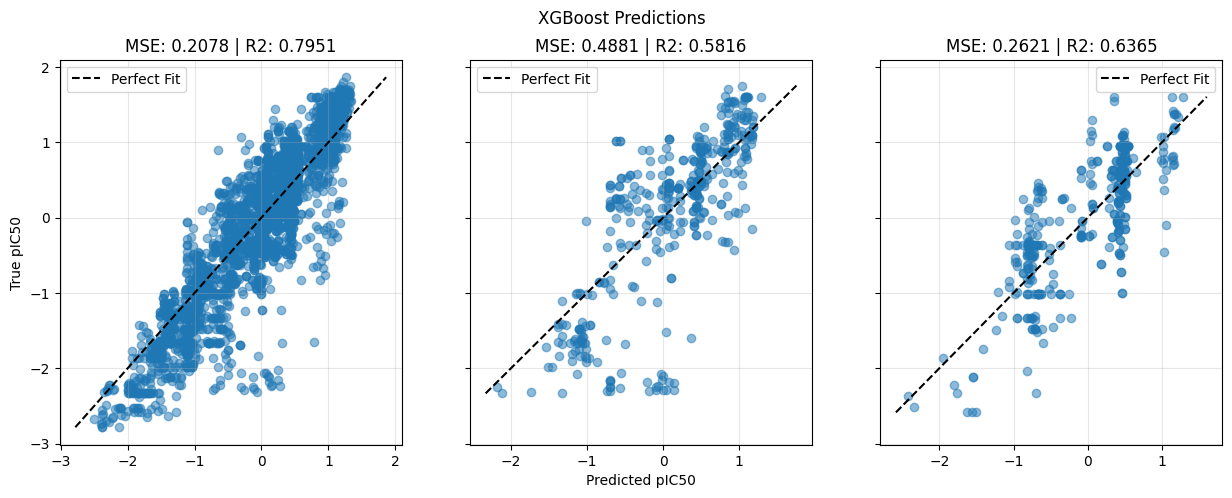

In [10]:
plot_xgboost_predictions(
    pred_train_mse_tuple=(y_pred_train, y_train, train_mse),
    pred_val_mse_tuple=(y_pred_val, y_val, val_mse),
    pred_test_mse_tuple=(y_pred_test, y_test, test_mse),
)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

df_gdta = pd.read_csv(
    os.path.join(
        ROOT, "data", "MDM2_Breaker", "processed", "graphdta_benchmark_results.csv"
    )
)

_, ax = plt.subplots(1, 1, figsize=(6, 6))
df_gdta.plot(
    x="pIC50_pred", y="pIC50", kind="scatter", alpha=0.5, color="blue", s=10, ax=ax
)
r2 = r2_score(df_gdta["pIC50"], df_gdta["pIC50_pred"])
mse = mean_squared_error(df_gdta["pIC50"], df_gdta["pIC50_pred"])
plt.xlim(-3, 2)
plt.ylim(-3, 2)
ax.set_aspect("equal", "box")
plt.plot([-3, 2], [-3, 2], "k--", alpha=0.5)
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title(f"Graph DTA (GCN) Predicted vs True pIC50\nR2: {r2:.4f}, MSE: {mse:.4f}")
plt.show()